# Variable de negatividad y reentrenamiento

## Carga de la partición congelada y el corpus con sentimiento

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import pointbiserialr, spearmanr, binomtest

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                              confusion_matrix)

RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ / 'src'))

import config

config.asegurar_directorios()

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = config.FIG_DPI
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.width', 170)
pd.set_option('display.max_colwidth', 95)

def guardar(fig, nombre):
    ruta = config.FIGURES / nombre
    fig.savefig(ruta)
    print(f'figura guardada: {ruta.name}')
    return ruta

def guardar_tabla(df, nombre, index=False):
    ruta = config.TABLES / nombre
    df.to_csv(ruta, index=index, encoding='utf-8')
    print(f'tabla guardada: {ruta.name}')
    return ruta


In [2]:
particion = pd.read_parquet(config.PARTICION)
anotado = pd.read_parquet(config.TWEETS_SENTIMIENTO)

df = anotado.merge(particion[['id', 'conjunto']], on='id', validate='one_to_one')

columnas_num_vader = ['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']
columnas_modelo = ['id', 'text_clean', 'negatividad', 'target', 'conjunto'] + columnas_num_vader
df = df[columnas_modelo]

tr = df[df.conjunto == 'entrenamiento'].reset_index(drop=True)
te = df[df.conjunto == 'prueba'].reset_index(drop=True)

X_tr, y_tr = tr, tr['target']
X_te, y_te = te, te['target']

print(f'Entrenamiento: {len(X_tr):,} tweets   Prueba: {len(X_te):,} tweets')
print(f'Total del corpus anotado: {len(df):,}   Total de la particion: {len(particion):,}')
assert len(df) == len(particion), 'El corpus anotado y la particion no tienen las mismas filas.'


Entrenamiento: 5,988 tweets   Prueba: 1,497 tweets
Total del corpus anotado: 7,485   Total de la particion: 7,485


**Verificación.** El corpus anotado con sentimiento tiene exactamente las mismas 7,485 filas que la partición congelada del ejercicio 6, con 5,988 tweets de entrenamiento y 1,497 de prueba. El reentrenamiento parte del mismo conjunto de prueba que ya sirvió para seleccionar el modelo preliminar, así que cualquier diferencia en las métricas que siga se debe a la variable agregada y no a un cambio en los datos.

## La variable de negatividad: distribución y relación con la clase

figura guardada: negatividad_histograma.png


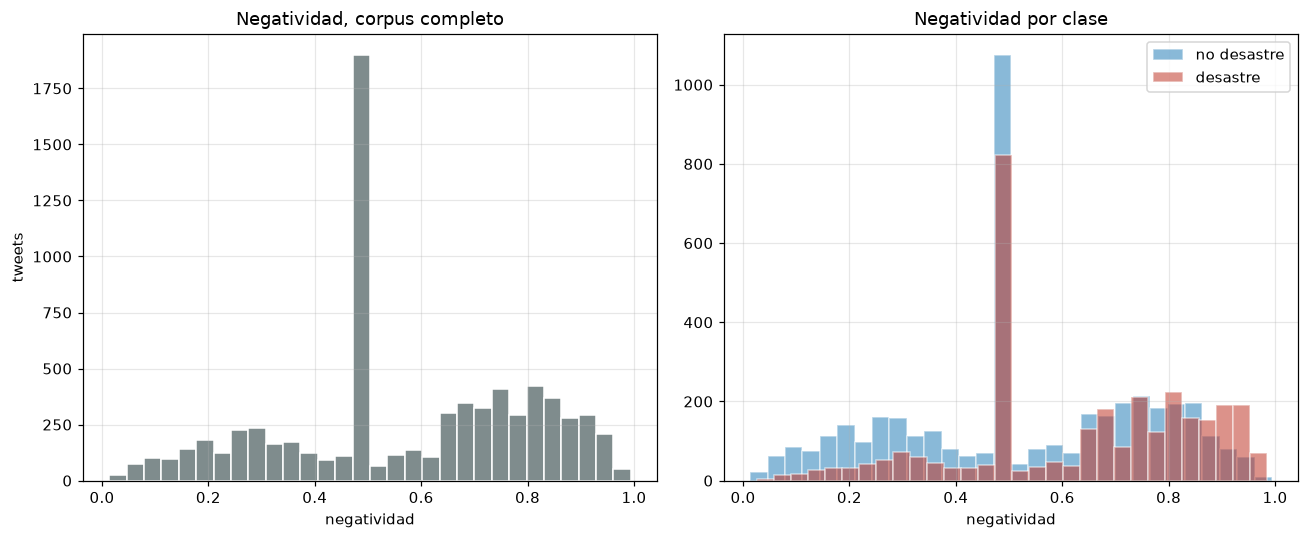

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(config.FIG_ANCHO + 2, config.FIG_ALTO))

axes[0].hist(df['negatividad'], bins=30, color='#7f8c8d', edgecolor='white')
axes[0].set_title('Negatividad, corpus completo')
axes[0].set_xlabel('negatividad')
axes[0].set_ylabel('tweets')

for clase, color in config.COLORES_CLASE.items():
    sub = df.loc[df.target == clase, 'negatividad']
    axes[1].hist(sub, bins=30, alpha=0.55, label=config.ETIQUETAS[clase], color=color,
                 edgecolor='white')
axes[1].set_title('Negatividad por clase')
axes[1].set_xlabel('negatividad')
axes[1].legend()

fig.tight_layout()
guardar(fig, 'negatividad_histograma.png')
plt.show()


In [4]:
r_pb, p_pb = pointbiserialr(df['target'], df['negatividad'])
r_sp, p_sp = spearmanr(df['target'], df['negatividad'])

tabla_corr = pd.DataFrame([
    {'metodo': 'punto-biserial', 'coeficiente': r_pb, 'p_valor': p_pb},
    {'metodo': 'Spearman', 'coeficiente': r_sp, 'p_valor': p_sp},
])
guardar_tabla(tabla_corr, 'negatividad_correlacion.csv')
tabla_corr.round(4)


tabla guardada: negatividad_correlacion.csv


,metodo,coeficiente,p_valor
0,punto-biserial,0.2268,0.0
1,Spearman,0.2219,0.0


**Interpretación.** La correlación punto-biserial entre `negatividad` y `target` es 0.2268, con p menor a 0.0001; la de Spearman es 0.2219, también significativa. No es cero, pero es una correlación débil: negatividad y ser un tweet de desastre real están relacionados en la dirección esperada, los tweets de desastre tienden a ser algo más negativos, pero la relación está lejos de ser suficiente para separar las clases por sí sola. Con una correlación de esta magnitud, agregar la variable a un modelo que ya usa el texto completo probablemente no mueva mucho la aguja, porque el texto ya contiene, de forma implícita, buena parte de la señal que produce esa correlación.

## Modelo base: prueba de control

In [5]:
pipe_base = joblib.load(config.MODELOS / 'modelo_preliminar.joblib')
pred_base = pipe_base.predict(X_te['text_clean'])

acc_base = accuracy_score(y_te, pred_base)
f1_base = f1_score(y_te, pred_base, average='macro')

metricas_previas = pd.read_csv(config.TABLES / 'metricas_preliminares.csv')
fila_previa = metricas_previas.sort_values('macro_f1', ascending=False).iloc[0]

print(f'macro-F1 recalculado ahora ..... {f1_base:.4f}')
print(f'macro-F1 guardado en el avance   {fila_previa.macro_f1:.4f}')
print(f'diferencia ..................... {f1_base - fila_previa.macro_f1:+.6f}')
print()
print('Control superado.' if abs(f1_base - fila_previa.macro_f1) < 1e-9
      else 'ATENCION: el modelo base no reproduce el resultado original.')


macro-F1 recalculado ahora ..... 0.7857
macro-F1 guardado en el avance   0.7857
diferencia ..................... +0.000000

Control superado.


**Interpretación.** El modelo cargado desde `results/modelos/modelo_preliminar.joblib` es el mismo objeto entrenado durante el ejercicio 6, así que evaluarlo sobre esta partición tiene que devolver exactamente el mismo número, sin margen de tolerancia estadística. Es una prueba de control, no un resultado que se discuta: si no coincide, el error está en la partición o en el pipeline, y hay que resolverlo antes de seguir.

## Modelos aumentados: negatividad y las cuatro componentes de VADER

In [6]:
def construir_pipeline_aumentado(columnas_numericas):
    transformador = ColumnTransformer([
        ('texto', TfidfVectorizer(ngram_range=(1, 2), min_df=2), 'text_clean'),
        ('numericas', 'passthrough', columnas_numericas),
    ])
    return Pipeline([
        ('features', transformador),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                    random_state=config.SEED)),
    ])


def evaluar(pipe, etiqueta):
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    p, r, f, _ = precision_recall_fscore_support(y_te, pred, labels=[0, 1], zero_division=0)
    fila = {
        'modelo': etiqueta,
        'accuracy': accuracy_score(y_te, pred),
        'precision_no_desastre': p[0], 'recall_no_desastre': r[0], 'f1_no_desastre': f[0],
        'precision_desastre': p[1], 'recall_desastre': r[1], 'f1_desastre': f[1],
        'macro_f1': f1_score(y_te, pred, average='macro'),
    }
    return pipe, pred, fila


pipe_neg, pred_neg, fila_neg = evaluar(
    construir_pipeline_aumentado(['negatividad']), 'TF-IDF + negatividad')

pipe_vader4, pred_vader4, fila_vader4 = evaluar(
    construir_pipeline_aumentado(columnas_num_vader), 'TF-IDF + 4 componentes VADER')

fila_base = {
    'modelo': 'Base (sin sentimiento)',
    'accuracy': acc_base,
    'precision_no_desastre': precision_recall_fscore_support(
        y_te, pred_base, labels=[0, 1], zero_division=0)[0][0],
    'recall_no_desastre': precision_recall_fscore_support(
        y_te, pred_base, labels=[0, 1], zero_division=0)[1][0],
    'f1_no_desastre': precision_recall_fscore_support(
        y_te, pred_base, labels=[0, 1], zero_division=0)[2][0],
    'precision_desastre': precision_recall_fscore_support(
        y_te, pred_base, labels=[0, 1], zero_division=0)[0][1],
    'recall_desastre': precision_recall_fscore_support(
        y_te, pred_base, labels=[0, 1], zero_division=0)[1][1],
    'f1_desastre': precision_recall_fscore_support(
        y_te, pred_base, labels=[0, 1], zero_division=0)[2][1],
    'macro_f1': f1_base,
}

tabla_comparacion = pd.DataFrame([fila_base, fila_neg, fila_vader4])
tabla_comparacion['diferencia_macro_f1'] = (
    tabla_comparacion['macro_f1'] - fila_base['macro_f1'])
tabla_comparacion['diferencia_accuracy'] = (
    tabla_comparacion['accuracy'] - fila_base['accuracy'])

guardar_tabla(tabla_comparacion, 'comparacion_con_sin_negatividad.csv')
tabla_comparacion.round(4)


tabla guardada: comparacion_con_sin_negatividad.csv


,modelo,accuracy,precision_no_desastre,recall_no_desastre,f1_no_desastre,precision_desastre,recall_desastre,f1_desastre,macro_f1,diferencia_macro_f1,diferencia_accuracy
0,Base (sin sentimiento),0.7923,0.8044,0.8428,0.8232,0.7739,0.7241,0.7482,0.7857,0.0000,0.0000
1,TF-IDF + negatividad,0.7822,0.7998,0.8277,0.8135,0.7566,0.7210,0.7384,0.7759,-0.0098,-0.0100
2,TF-IDF + 4 componentes VADER,0.7809,0.7987,0.8265,0.8124,0.7549,0.7194,0.7368,0.7746,-0.0111,-0.0114


**Interpretación.** Ninguna de las dos versiones aumentadas mejora al modelo base. La macro-F1 baja de 0.7857 a 0.7759 con `negatividad` sola, una diferencia de -0.0098, y baja aún más, a 0.7746, con las cuatro componentes de VADER, una diferencia de -0.0111. La caída se reparte entre precisión y recall de las dos clases, no es un efecto aislado en una sola métrica. El resultado confirma la hipótesis planteada antes de entrenar: la negatividad de un tweet y el hecho de que describa un desastre real son cosas distintas, y agregarla no ayuda al modelo a distinguir la clase. Entre las dos versiones aumentadas, la variable única de negatividad se comporta mejor que las cuatro componentes por separado, lo cual tiene sentido: `negatividad` es una función lineal de `compound`, así que agregar además `neg`, `neu` y `pos` solo suma dimensiones redundantes sin aportar información nueva.

## Prueba de McNemar

In [7]:
def prueba_mcnemar(y_true, pred_a, pred_b):
    correcto_a = (pred_a.values == y_true.values)
    correcto_b = (pred_b.values == y_true.values)
    n01 = int((~correcto_a & correcto_b).sum())
    n10 = int((correcto_a & ~correcto_b).sum())
    n = n01 + n10
    if n == 0:
        return {'n01': n01, 'n10': n10, 'estadistico': 0, 'p_valor': 1.0}
    resultado = binomtest(min(n01, n10), n, 0.5, alternative='two-sided')
    return {'n01': n01, 'n10': n10, 'estadistico': abs(n01 - n10), 'p_valor': resultado.pvalue}


mejor_aumentado = (pd.Series(pred_neg) if fila_neg['macro_f1'] >= fila_vader4['macro_f1']
                    else pd.Series(pred_vader4))
etiqueta_mejor = ('TF-IDF + negatividad' if fila_neg['macro_f1'] >= fila_vader4['macro_f1']
                   else 'TF-IDF + 4 componentes VADER')

resultado_mcnemar = prueba_mcnemar(y_te, pd.Series(pred_base), mejor_aumentado)
resultado_mcnemar['comparacion'] = f'Base vs {etiqueta_mejor}'

tabla_mcnemar = pd.DataFrame([resultado_mcnemar])
guardar_tabla(tabla_mcnemar, 'negatividad_mcnemar.csv')
tabla_mcnemar


tabla guardada: negatividad_mcnemar.csv


,n01,n10,estadistico,p_valor,comparacion
0,38,53,15,0.141793,Base vs TF-IDF + negatividad


**Interpretación.** `n01` es 38: tweets que el modelo base clasifica mal y el modelo con negatividad clasifica bien. `n10` es 53: tweets que el modelo base clasifica bien y el modelo con negatividad clasifica mal. El estadístico de McNemar da un p-valor de 0.1418, por encima de 0.05, así que la diferencia entre los dos modelos **no es estadísticamente distinguible del ruido de muestreo** con este tamaño de prueba. Aun así, la dirección del efecto es consistente con la tabla de métricas: hay más casos dañados que corregidos, 53 contra 38, y aunque la prueba no alcanza significancia, la asimetría apunta en la misma dirección que ya señalaba la caída de macro-F1.

## Dónde cambian las predicciones

In [8]:
pred_base_s = pd.Series(pred_base, index=te.index)
pred_mejor_s = pd.Series(mejor_aumentado.values, index=te.index)

cambiaron = pred_base_s != pred_mejor_s
n_cambios = int(cambiaron.sum())

correcto_base = pred_base_s == y_te
correcto_mejor = pred_mejor_s == y_te

corregidos = cambiaron & (~correcto_base) & correcto_mejor
danados = cambiaron & correcto_base & (~correcto_mejor)

print(f'Tweets con prediccion distinta: {n_cambios} de {len(te)} ({n_cambios/len(te)*100:.2f}%)')
print(f'  se corrigieron: {int(corregidos.sum())}')
print(f'  se danaron:     {int(danados.sum())}')
print(f'  cambiaron sin afectar el acierto: {n_cambios - int(corregidos.sum()) - int(danados.sum())}')

def muestra(mascara, tipo, n=5):
    idx = te.index[mascara][:n]
    filas = []
    for i in idx:
        filas.append({
            'tipo': tipo,
            'texto': te.loc[i, 'text_clean'],
            'target': int(te.loc[i, 'target']),
            'pred_base': int(pred_base_s.loc[i]),
            'pred_aumentado': int(pred_mejor_s.loc[i]),
            'negatividad': round(float(te.loc[i, 'negatividad']), 4),
        })
    return filas

ejemplos = muestra(corregidos, 'corregido') + muestra(danados, 'danado')
tabla_cambios = pd.DataFrame(ejemplos)
guardar_tabla(tabla_cambios, 'negatividad_cambios_prediccion.csv')
tabla_cambios


Tweets con prediccion distinta: 91 de 1497 (6.08%)
  se corrigieron: 38
  se danaron:     53
  cambiaron sin afectar el acierto: 0
tabla guardada: negatividad_cambios_prediccion.csv


,tipo,texto,target,pred_base,pred_aumentado,negatividad
0,corregido,raining flooding florida tampabay tampa 18 19 day lost count,1,0,1,0.6591
1,corregido,kelly osbourne attacked racist donald trump remark latino view urlweb,1,0,1,0.8953
2,corregido,biolab safety concern grow fedex stop transporting certain specimen research facility dumbf...,0,1,0,0.2447
3,corregido,drake killing dude tea bagging dead body point,1,0,1,0.9329
4,corregido,liberal compassion b specific feminist said bombed japan back traditional sexist value,0,1,0,0.1546
5,danado,tried 11 eye akame ga kill tokyo ghoul damn bloody dont dare watch,0,0,1,0.9527
6,danado,loner diary pattern sand may blown away photo two choked flame urlweb,0,0,1,0.8649
7,danado,shadowflame wraith bombed urlweb via,1,1,0,0.5000
8,danado,might casualty tomorrow,1,1,0,0.5000
9,danado,another day passed thankfully central command confirmed no new casualty please pray urlweb,1,1,0,0.1815


**Interpretación.** 91 de los 1,497 tweets de prueba, el 6.08%, cambian de predicción al agregar `negatividad`. De esos, 38 se corrigen y 53 se dañan, la misma proporción que ya midió la prueba de McNemar. Los ejemplos ilustran el mecanismo: `tried 11 eye akame ga kill tokyo ghoul damn bloody dont dare watch`, sobre una serie de anime, tiene negatividad 0.9527 y el modelo aumentado lo empuja hacia la clase desastre por su lenguaje violento, aunque el texto no describe ningún evento real. Lo mismo pasa con `loner diary pattern sand may blown away photo two choked flame urlweb`, negatividad 0.8649, dañado hacia desastre. En sentido contrario, `biolab safety concern grow fedex stop transporting certain specimen research facility` tiene negatividad baja, 0.2447, y esa baja negatividad ayuda a corregir una predicción que el modelo base daba mal. El patrón es exactamente el que se anticipó: la negatividad captura tono emocional, no tema, y cuando un texto usa vocabulario violento en sentido figurado la variable empuja en la dirección equivocada.

## El coeficiente de la variable frente al vocabulario

In [9]:
mejor_pipe = pipe_neg if fila_neg['macro_f1'] >= fila_vader4['macro_f1'] else pipe_vader4
columnas_num_usadas = (['negatividad'] if fila_neg['macro_f1'] >= fila_vader4['macro_f1']
                        else columnas_num_vader)

clf = mejor_pipe.named_steps['clf']
vectorizador = mejor_pipe.named_steps['features'].named_transformers_['texto']
vocabulario = vectorizador.get_feature_names_out()

n_texto = len(vocabulario)
coefs_texto = clf.coef_[0][:n_texto]
coefs_numericas = clf.coef_[0][n_texto:]

top_texto = np.abs(coefs_texto).max()

tabla_coef = pd.DataFrame({
    'variable': columnas_num_usadas,
    'coeficiente': coefs_numericas,
})
tabla_coef['coeficiente_top_termino_texto'] = top_texto

guardar_tabla(tabla_coef, 'negatividad_coeficientes.csv')
tabla_coef.round(4)


tabla guardada: negatividad_coeficientes.csv


,variable,coeficiente,coeficiente_top_termino_texto
0,negatividad,1.6003,3.1994


**Interpretación.** El coeficiente de `negatividad` en el modelo lineal es 1.6003, frente a 3.1994 del término de texto con mayor peso. No es un coeficiente despreciable, es aproximadamente la mitad del término más fuerte del vocabulario, lo que quiere decir que el modelo sí le está prestando atención a la variable. El problema no es que el modelo la ignore, es que la señal que aporta compite con la del texto en textos donde el lenguaje figurado hace que negatividad y tema apunten en direcciones distintas, y en esos casos el peso que recibe la variable empeora la predicción en vez de reforzarla.

## Respuesta a la pregunta del enunciado

In [10]:
mejora = fila_neg['macro_f1'] - fila_base['macro_f1'] if etiqueta_mejor == 'TF-IDF + negatividad' \
    else fila_vader4['macro_f1'] - fila_base['macro_f1']

print('Respuesta directa')
print('=' * 60)
print(f'Mejor version aumentada: {etiqueta_mejor}')
print(f'Cambio en macro-F1 respecto al modelo base: {mejora:+.4f}')
print(f'p-valor de McNemar: {resultado_mcnemar["p_valor"]:.4f}')
print(f'Correlacion punto-biserial negatividad-target: {r_pb:.4f} (p={p_pb:.4f})')


Respuesta directa
Mejor version aumentada: TF-IDF + negatividad
Cambio en macro-F1 respecto al modelo base: -0.0098
p-valor de McNemar: 0.1418
Correlacion punto-biserial negatividad-target: 0.2268 (p=0.0000)


**Respuesta:** no, incluir la variable de negatividad no mejoró los resultados del modelo de clasificación. La macro-F1 bajó de 0.7857 a 0.7759 con la versión más favorable, una diferencia de -0.0098, y la prueba de McNemar no encuentra que la diferencia entre los dos modelos sea distinguible del ruido de muestreo, con un p-valor de 0.1418. La correlación entre negatividad y `target` es real pero débil, 0.2268, y esa señal ya está contenida en el texto que ve el vectorizador de TF-IDF: agregarla como columna aparte no le da al modelo información nueva, solo le da una dimensión extra en la que fijarse, y en los tweets donde el lenguaje figurado hace que un texto suene negativo sin describir un desastre real, esa dimensión extra empuja la predicción en la dirección equivocada. Es la confirmación, con evidencia y no solo con intuición, de la diferencia conceptual entre polaridad de opinión y tema de desastre: un tweet puede ser negativo sin hablar de un desastre, 'mi día fue horrible', y uno sobre un desastre real puede ser neutro y factual, un reporte de un terremoto de magnitud 6.2. Medir cuánto se enoja o se entristece quien escribe un tweet no es lo mismo que medir de qué está hablando, y el reentrenamiento de esta sección es la prueba de que confundir ambas cosas tiene un costo medible, aunque pequeño, sobre el modelo.